# Rice yield prediction from UAS features: PCA + LASSO (Hypothesis 1, Approach 1, M1) — LORO 2021

Reproduction of **Farag et al., "Manifold and spatiotemporal learning on multispectral unoccupied aerial system imagery for phenotype prediction"**, *The Plant Phenome Journal* (2026), DOI [10.1002/ppj2.70006](https://doi.org/10.1002/ppj2.70006).

**Author source code** (pinned commit [`2e9a01b`](https://github.com/FareedFarag/TPPJ-Modeling-Code/tree/2e9a01bee7d2c604ef16e7ed1c56361e7de5406f)): this notebook re-executes the author's own notebook code for **Hypothesis 1, proposed modeling approach 1 (PCA-based dimension reduction) with M1 = LASSO**, within-season **LORO 2021** evaluation (`Hypothesis_1/LORO/2021/Proposed_Models/Proposed_Modeling_Approach_1/H1A1M1.ipynb` and `Hypothesis_1/LORO/2021/Testing/LORO.ipynb`), with minimal documented adaptations.

**Scientific scope (PARTIAL demonstration):** on the author's tabular 2021 UAV-derived feature dataset, reproduce the author's deterministic leave-one-replicate-out (LORO) split, the PCA embedding of scaled vegetation-index/texture features, LassoCV model tuning, and held-out-replicate prediction of grain yield — including inference with the authors' own saved `PCA_EMBEDDING` / `H1A1M1` joblib artifacts and comparison against the authors' committed reference `predictions.csv`.

**Not covered:** the UMAP approach 2, the XGBoost (M2) variant, cross-season LOYO evaluation, and all of Hypothesis 2 (PUMAP / 3D-CNN on raw images — those raw images are not publicly hosted yet, per the authors' README). A single-season LORO-2021 run does **not** verify the paper's dataset-level results.

**実行内容(日本語):** 著者公開コード(コミット `2e9a01b`)のうち、仮説1・アプローチ1(PCA次元削減)+LASSO(M1)の季節内 LORO 2021 評価をそのまま再実行します。2021年のUAV特徴量CSVを取得し、著者と同一の決定論的LORO分割、標準化、PCA埋め込み、LassoCVチューニング、テスト区画の収量予測と指標計算を行い、著者自身の学習済みモデルとコミット済み参照予測 `predictions.csv` と照合します。UMAP・XGBoost・LOYO・仮説2(生画像)は対象外です。

**Execution status:** authored, not yet executed; validated end-to-end on a fresh Colab CPU runtime (see the final cells and the project report).


## Runtime selection

**This notebook runs on CPU only.** The reproduced subsection is pure scikit-learn (PCA + LASSO) on a ~1.8 MB tabular dataset; the authors' code for this approach contains no GPU path, and a GPU adds nothing scientifically. In Colab select **Runtime → Change runtime type → CPU** (the default), then **Runtime → Run all**.

Expected size: ~2 MB of downloads; no package installs (all libraries used are preinstalled in Colab); execution well under 15 minutes. Measured wall times for the validation run are stated in the accompanying project report.

**ランタイム(日本語):** このノートブックはCPUのみで動作します(純scikit-learn処理のためGPU不要)。「ランタイム → すべてのセルを実行」でそのまま実行できます。ダウンロードは約2MB、追加のパッケージ導入は不要です。


### Environment check

Prints the Python and key library versions so the executed environment is on record. The authors pinned Python 3.10.11 and scikit-learn ^1.2.2 (repo `pyproject.toml`); Colab ships a newer stack, so the one API-level adaptation needed is defined here: `root_mean_squared_error` replaces the authors' `mean_squared_error(..., squared=False)`, whose `squared` argument was removed in newer scikit-learn (numerically identical).

**環境確認(日本語):** Pythonと主要ライブラリのバージョンを記録します。著者はPython 3.10.11 / scikit-learn 1.2.x を使用しましたが、Colabのより新しいscikit-learn向けにRMSE計算のみ互換ヘルパーを用意します(数値は同一)。

In [ ]:
import sys
import numpy as np
import pandas as pd
import sklearn
import joblib

print("Python:", sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

from sklearn.metrics import mean_squared_error, mean_absolute_error
try:  # sklearn >= 1.4; the authors used mean_squared_error(..., squared=False), removed in newer sklearn
    from sklearn.metrics import root_mean_squared_error
    def rmse(y_true, y_pred):
        return root_mean_squared_error(y_true, y_pred)
except ImportError:
    def rmse(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
numpy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
joblib: 1.6.0


### Download the pinned inputs (dataset, author-saved models, reference predictions)

Downloads exactly four files from the authors' repository at pinned commit `2e9a01bee7d2…` and verifies each one's size **and git blob SHA-1** (computed from the downloaded bytes) before use:

| File | Role |
|---|---|
| `Hypothesis_1/Datasets/2021/Dataset_2021.csv` | 2021 UAV-derived tabular features + agronomic labels (the input) |
| `…/Proposed_Modeling_Approach_1/Saved_Models/PCA_EMBEDDING` | authors' fitted PCA embedding (joblib) |
| `…/Proposed_Modeling_Approach_1/Saved_Models/H1A1M1` | authors' tuned LASSO model (joblib) |
| `Hypothesis_1/LORO/2021/Outputs/predictions.csv` | authors' committed reference test-set predictions (quantitative comparison) |

All bytes stay on the Colab VM under `/content`.

**入力のダウンロード(日本語):** 著者リポジトリのピン留めしたコミットから、2021年特徴量CSV・著者保存のPCA埋め込みとLASSOモデル・参照予測CSVの4ファイルのみを取得し、サイズとgit blob SHA-1で検証します。データはColab VM上(/content)にのみ置かれます。

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

COMMIT = "2e9a01bee7d2c604ef16e7ed1c56361e7de5406f"
RAW = "https://raw.githubusercontent.com/FareedFarag/TPPJ-Modeling-Code/" + COMMIT

FILES = {  # repo path -> (local path, expected size in bytes, expected git blob SHA-1)
    "Hypothesis_1/Datasets/2021/Dataset_2021.csv": (
        "data/Dataset_2021.csv", 1825052, "77ff6b33daaa9ef39ca7f744f014626f537a78f2"),
    "Hypothesis_1/LORO/2021/Proposed_Models/Proposed_Modeling_Approach_1/Saved_Models/PCA_EMBEDDING": (
        "models/PCA_EMBEDDING", 22671, "15c3c38732300e24bf336669f460ebd1f9abbeb4"),
    "Hypothesis_1/LORO/2021/Proposed_Models/Proposed_Modeling_Approach_1/Saved_Models/H1A1M1": (
        "models/H1A1M1", 6019, "aaf4ed800aa1eebfbfd1ecfe16bd4cdffd99d17d"),
    "Hypothesis_1/LORO/2021/Outputs/predictions.csv": (
        "reference/predictions.csv", 10393, "6f7cc70b3e102fb35de82f20f8643cd4cc24f69c"),
}

def blob_sha1(path: Path) -> str:
    content = path.read_bytes()
    return hashlib.sha1(b"blob %d\x00" % len(content) + content).hexdigest()

for repo_path, (local, size, sha) in FILES.items():
    local_path = Path("/content") / local
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if not local_path.exists():
        urllib.request.urlretrieve(f"{RAW}/{repo_path}", local_path)
    assert local_path.stat().st_size == size, f"size mismatch: {local}"
    assert blob_sha1(local_path) == sha, f"blob sha1 mismatch: {local}"
    print(f"verified {local}: {size} bytes, blob sha1 {sha[:12]}…")

verified data/Dataset_2021.csv: 1825052 bytes, blob sha1 77ff6b33daaa…
verified models/PCA_EMBEDDING: 22671 bytes, blob sha1 15c3c3873230…
verified models/H1A1M1: 6019 bytes, blob sha1 aaf4ed800aa1…


verified reference/predictions.csv: 10393 bytes, blob sha1 6f7cc70b3e10…


### Load the 2021 dataset and confirm its schema

The authors load `Dataset_2021.csv`, sort by `Date` then `Plot_Number`, and treat **columns 0–16 as labels/meta** (including `Date`, `Plot_Number`, `Rice_Cultivar`, `Experiment_Name`, `Bay_Length`, `Nitrogen_Rate`, `Replicate`, `Yield`) and **columns 17 onward as the UAV-derived feature block** — this is the exact indexing used throughout `H1A1M1.ipynb` and `Testing/LORO.ipynb`. We confirm that split against the actual file before relying on it.

**データ読み込み(日本語):** CSVを読み込み、列の並び(先頭17列がラベル/メタ、17列目以降がUAV特徴量)を実際のファイルで確認します。著者コードと同一のインデックス前提を検証する工程です。

In [ ]:
df_2021_raw = pd.read_csv("/content/data/Dataset_2021.csv")
print("rows, cols:", df_2021_raw.shape)
print("first 17 columns:", list(df_2021_raw.columns[:17]))
print("feature columns (17:):", len(df_2021_raw.columns) - 17, "columns, first 8:",
      list(df_2021_raw.columns[17:25]))
required = {"Date", "Plot_Number", "Rice_Cultivar", "Experiment_Name",
            "Bay_Length", "Nitrogen_Rate", "Replicate", "Yield", "Heading_100"}
missing = required - set(df_2021_raw.columns)
assert not missing, f"expected label columns missing: {missing}"
assert "Vegetation_Fraction" in df_2021_raw.columns

rows, cols: (2844, 67)
first 17 columns: ['Date', 'Plot_Number', 'Rice_Cultivar', 'Experiment_Name', 'Bay_Length', 'Nitrogen_Rate', 'Replicate', 'Yield', 'Heading_25', 'Heading_50', 'Heading_100', 'Percent_Stand', 'Percent_Lodge', 'Final_Lodge', 'SPAD', 'Leaf1_Temp', 'Leaf2_Temp']
feature columns (17:): 50 columns, first 8: ['Thermal', 'NDWI', 'EVI', 'NAVI', 'GNDVI', 'Cigreen', 'RENDVI', 'TGI']


### Input preview: yield distribution and flight-date composition

Before any modeling, look at the actual data: the grain yield (`Yield`) distribution and the number of unique plots per flight date. This is the input the whole reproduction operates on; nothing is modeled yet. This histogram is **created for this notebook**, not an author figure.

**入力プレビュー(日本語):** モデル化の前に、実際のデータ(収量の分布、飛行日ごとの区画数)を可視化します。このヒストグラムは本ノートブックで追加作成した図であり、著者の論文図ではありません。

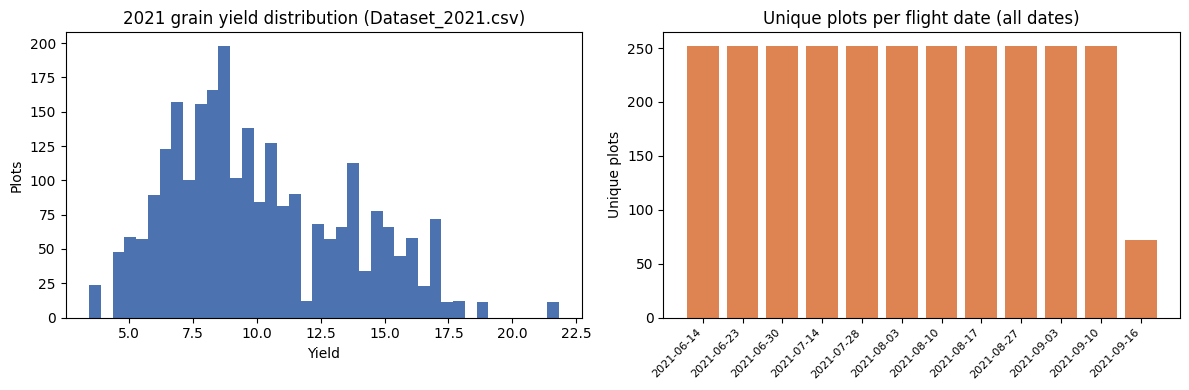

count    2536.00
mean       10.11
std         3.51
min         3.44
25%         7.41
50%         9.41
75%        12.85
max        21.82
Name: Yield, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_2021_raw["Yield"].dropna(), bins=40, color="#4c72b0")
axes[0].set_xlabel("Yield")
axes[0].set_ylabel("Plots")
axes[0].set_title("2021 grain yield distribution (Dataset_2021.csv)")

counts = df_2021_raw.groupby("Date")["Plot_Number"].nunique()
axes[1].bar(range(len(counts)), counts.values, color="#dd8452")
axes[1].set_xticks(range(len(counts)), counts.index, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Unique plots")
axes[1].set_title("Unique plots per flight date (all dates)")
plt.tight_layout()
plt.show()
print(df_2021_raw["Yield"].describe().round(2))

### Author preprocessing (verbatim)

Verbatim from `H1A1M1.ipynb` code cell 3 (identical in `Testing/LORO.ipynb` cell 3): sort by `Date`, `Plot_Number`; drop rows with missing `Yield`; keep only the four **late-booting-stage** flight dates (`2021-06-14`, `2021-06-23`, `2021-06-30`, `2021-07-28`); drop the `Vegetation_Fraction` feature column. This defines the exact population of the LORO-2021 experiment.

**前処理(日本語):** 著者コードのまま:日付・区画でソートし、収量欠損行を除外、穂孕み期後半の4飛行日のみを残し、`Vegetation_Fraction` 列を削除します。

In [ ]:
LATE_BOOT_DATES = ["2021-06-14", "2021-06-23", "2021-06-30", "2021-07-28"]

df_2021 = df_2021_raw.sort_values(by=["Date", "Plot_Number"])

# remove missing yield
df_2021 = df_2021[df_2021["Yield"].notna()]

# Only keep dates that occur on/before late booting stage
df_2021["Date"] = pd.to_datetime(df_2021["Date"]).dt.strftime("%Y-%m-%d")
df_2021 = df_2021[df_2021["Date"].isin(LATE_BOOT_DATES)]

# remove vegetation fraction
df_2021.drop("Vegetation_Fraction", axis=1, inplace=True)

print("rows after preprocessing:", len(df_2021))
print("dates:", sorted(df_2021["Date"].unique()))
print("feature columns after drop:", len(df_2021.columns) - 17)

rows after preprocessing: 896
dates: ['2021-06-14', '2021-06-23', '2021-06-30', '2021-07-28']
feature columns after drop: 49


### Deterministic LORO split (verbatim logic, condensed printing)

Verbatim splitting logic from `H1A1M1.ipynb` cell 5 (identical in `Testing/LORO.ipynb` cell 5): for every `Experiment_Name` × `Rice_Cultivar` × `Nitrogen_Rate` group, one **replicate** is drawn with `np.random.seed(seedCounter)` (counter starting at 100, incremented per group) and its plots become the held-out test set; all other replicates become training plots. This is **LORO — leave-one-replicate-out** — deterministic and reproducible. Presentation-only change: the authors' per-group printouts are condensed to summary counts (the selection logic itself is untouched).

**LORO分割(日本語):** 試験×品種×窒素処理ごとに1反復をシード付きで抽出してテスト区画とします(著者と同一の決定論的手順)。表示のみ要約形にし、選択ロジックは著者コードのままです。

In [ ]:
seedCounter = 100
trainPlots = []
testPlots = []
nGroups = 0
tmp = df_2021[df_2021["Date"] == df_2021["Date"].unique()[0]]

for e in tmp["Experiment_Name"].unique():
    for c in tmp[tmp["Experiment_Name"] == e]["Rice_Cultivar"].unique():
        for n in tmp[(tmp["Experiment_Name"] == e) & (tmp["Rice_Cultivar"] == c)][
            "Nitrogen_Rate"
        ].unique():
            replicates = tmp[
                (tmp["Experiment_Name"] == e)
                & (tmp["Rice_Cultivar"] == c)
                & (tmp["Nitrogen_Rate"] == n)
            ]["Replicate"].unique()

            # set seed for each random pick for reproducibility
            np.random.seed(seedCounter)
            picked = np.random.choice(replicates)
            seedCounter += 1
            nGroups += 1

            train = tmp[
                (tmp["Experiment_Name"] == e)
                & (tmp["Rice_Cultivar"] == c)
                & (tmp["Nitrogen_Rate"] == n)
                & (tmp["Replicate"] != picked)
            ]["Plot_Number"].values

            test = tmp[
                (tmp["Experiment_Name"] == e)
                & (tmp["Rice_Cultivar"] == c)
                & (tmp["Nitrogen_Rate"] == n)
                & (tmp["Replicate"] == picked)
            ]["Plot_Number"].values

            trainPlots.extend(train)
            testPlots.extend(test)

print(f"{nGroups} experiment/cultivar/nitrogen groups processed")
print(f"train plots: {len(set(trainPlots))}, test plots: {len(set(testPlots))}")

32 experiment/cultivar/nitrogen groups processed
train plots: 151, test plots: 73


### Feature scaling (adapted assignment only)

Verbatim operation from `H1A1M1.ipynb` cell 6: a single `StandardScaler` is fitted on the training plots' feature columns (index 17:) and applied to them; the test transform happens later with the same fitted scaler. Two presentation-level adaptations with identical numerics: (1) `dfTrain`/`dfTest` are explicit `.copy()` objects so column assignment cannot silently fail under pandas copy-on-write; (2) assignment targets the named feature columns instead of chained `.iloc` assignment.

**標準化(日本語):** 著者と同じ `StandardScaler` を訓練区画の特徴量(17列目以降)に適用します。pandasの仕様変化に備えて代入方法のみ調整しています(数値・操作は同一)。テスト側の変換は後のセルで同じスケーラーで行います。

In [ ]:
from sklearn.preprocessing import StandardScaler

dfTrain = df_2021[df_2021["Plot_Number"].isin(trainPlots)].copy()
dfTest = df_2021[df_2021["Plot_Number"].isin(testPlots)].copy()

feature_cols = dfTrain.columns[17:]

scaler = StandardScaler()
dfTrain[feature_cols] = scaler.fit_transform(dfTrain[feature_cols])
dfTest[feature_cols] = scaler.transform(dfTest[feature_cols])

dfUavTrain = dfTrain[feature_cols]
dfLabelsTrain = dfTrain.iloc[:, :17]
print("scaled training feature matrix:", dfUavTrain.shape)

scaled training feature matrix: (604, 49)


### Fit the PCA embedding on training plots (verbatim)

Verbatim from `H1A1M1.ipynb` cell 8: PCA with **all** components is fitted on the scaled training features; the transform is concatenated with the label columns and components are renamed `PCA_1…PCA_k`. The cumulative explained variance of the first 10 components is printed — the authors retain 10 PCs.

**PCA学習(日本語):** 標準化済み訓練特徴量に全主成分のPCAを適合させます(著者コードのまま)。最初の10主成分の累積寄与率を表示します。

In [ ]:
from sklearn.decomposition import PCA

# retain all components for now
embedding = PCA().fit(dfUavTrain)

dfEmbeddingTrain = pd.concat(
    [
        dfLabelsTrain.reset_index(drop=True),
        pd.DataFrame(embedding.transform(dfUavTrain)),
    ],
    axis=1,
)

# rename components
for i in range(len(dfLabelsTrain.columns), len(dfEmbeddingTrain.columns), 1):
    dfEmbeddingTrain.rename(
        columns={
            dfEmbeddingTrain.columns[i]: "PCA_"
            + str(i - len(dfLabelsTrain.columns) + 1)
        },
        inplace=True,
    )

print("components:", embedding.n_components_)
print("explained variance ratio of first 10 PCs:",
      round(embedding.explained_variance_ratio_[0:10].sum(), 4))

components: 49
explained variance ratio of first 10 PCs: 0.9843


### PCA score plot colored by flight date (author's cell 12)

Reproduces the author's diagnostic `sns.scatterplot` of `PCA_1` vs `PCA_2` colored by `Date` — a direct check that the embedding is computed and structured exactly as in `H1A1M1.ipynb`.

**PCA散布図(日本語):** 著者ノートブックのセルと同様に、PCA第1・第2主成分を飛行日別に色分けして表示します。

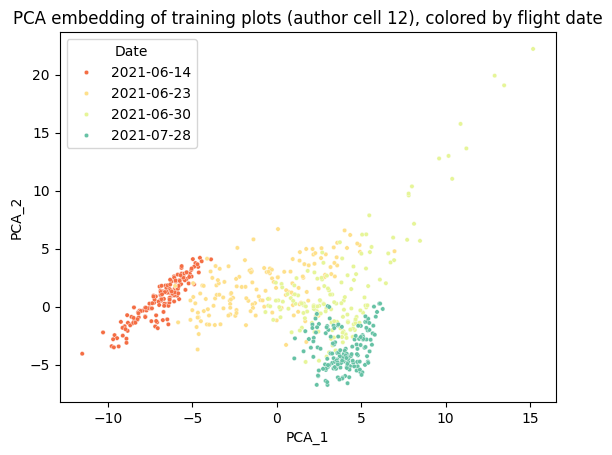

In [ ]:
import seaborn as sns
sns.scatterplot(
    dfEmbeddingTrain, x="PCA_1", y="PCA_2", hue="Date", palette="Spectral", s=10
)
plt.title("PCA embedding of training plots (author cell 12), colored by flight date")
plt.show()

### Scree plot of explained variance (author's cell 13)

Reproduces the author's proportion-of-variance-explained line plot with the dashed marker at 10 PCs — the basis for the authors' choice of the first 10 components.

**寄与率のスクリーープロット(日本語):** 著者セルと同様に主成分ごとの寄与率を折れ線で示します(破線は10主成分の位置)。

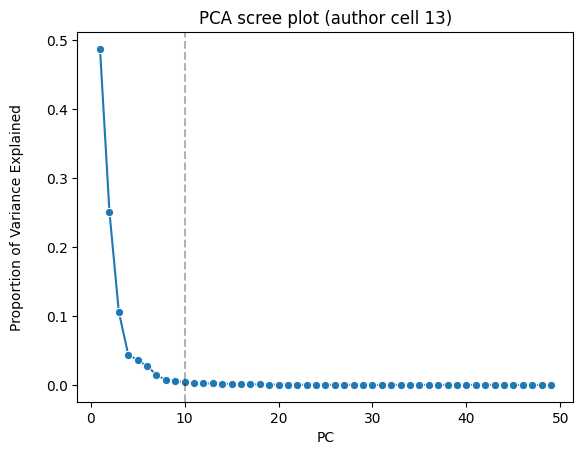

In [ ]:
sns.lineplot(
    x=np.arange(len(dfUavTrain.columns)) + 1,
    y=embedding.explained_variance_ratio_,
    marker="o",
)
plt.axvline(x=10, linestyle="dashed", alpha=0.3, color="black")

plt.xlabel("PC")
plt.ylabel("Proportion of Variance Explained\n")
plt.title("PCA scree plot (author cell 13)")
plt.show()

### Loadings biplot (author's cell 14)

Reproduces the author's biplot: arrows show each feature's loading on PC1/PC2, dots are plots (rescaled for display) colored by date. Feature names come from the actual dataset columns.

**バイプロット(日本語):** 著者セルと同様に、特徴量の主成分負荷量を矢印で、区画を点で示します。

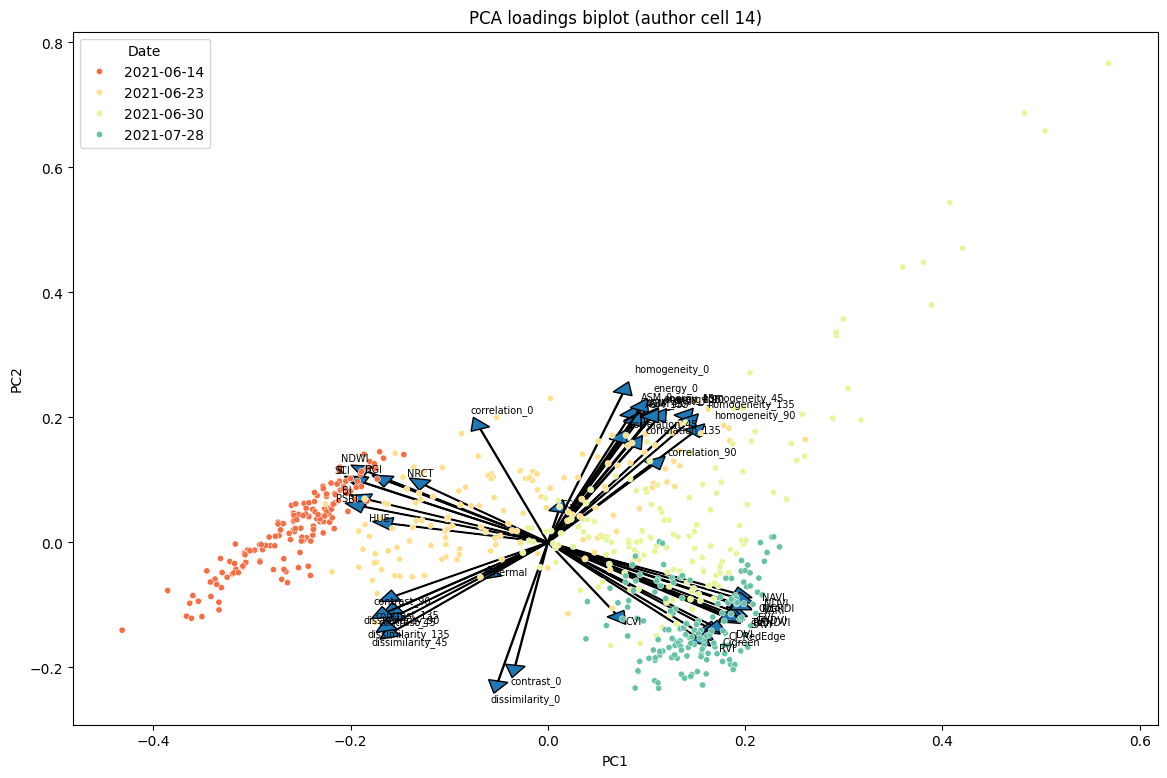

In [ ]:
plt.figure(figsize=(14, 9))

for i, feature in enumerate(dfUavTrain.columns):
    plt.arrow(
        0,
        0,
        embedding.components_[0, i],
        embedding.components_[1, i],
        head_width=0.02,
        head_length=0.02,
    )
    plt.text(
        embedding.components_[0, i] * 1.15,
        embedding.components_[1, i] * 1.15,
        feature,
        fontsize=7,
    )

sns.scatterplot(
    x=dfEmbeddingTrain["PCA_1"]
    * (1.0 / (dfEmbeddingTrain["PCA_1"].max() - dfEmbeddingTrain["PCA_1"].min())),
    y=dfEmbeddingTrain["PCA_2"]
    * (1.0 / (dfEmbeddingTrain["PCA_2"].max() - dfEmbeddingTrain["PCA_2"].min())),
    hue=dfEmbeddingTrain["Date"],
    palette="Spectral",
    s=20,
)

plt.xlabel("PC1", fontsize=10)
plt.ylabel("PC2", fontsize=10)
plt.title("PCA loadings biplot (author cell 14)")
plt.show()

### Phenology helper columns (author's cell 11)

Verbatim from `H1A1M1.ipynb` cell 11: derives emergence/heading day-of-year and days-to-100%-heading per row. Note (checked against the author's own subsequent cell): these derived columns are **not** part of the final model matrix — the author's later selection keeps only `Date`…`PCA_10` before pivoting — so they are reproduced here for faithfulness but do not affect the result.

**フェノロジー補助列(日本語):** 著者セルのまま出穂・抽穂起点からの日数を計算します。ただし著者の後続セルと同じく最終モデル行列には含まれないため、結果には影響しません。

In [ ]:
import datetime

tmp = dfEmbeddingTrain.copy()
tmp["Emergence_DOY"] = 140
tmp.loc[tmp["Experiment_Name"] == "Mini_Core", "Emergence_DOY"] = 139

# add 100% heading dates
tmp["Heading_100_DOY"] = tmp["Emergence_DOY"] + tmp["Heading_100"]

# calculate days to 100% heading
tmp["Days_to_100%_Heading"] = tmp.apply(
    lambda x: datetime.datetime.strptime(x["Date"], "%Y-%m-%d").timetuple().tm_yday
    - x["Heading_100_DOY"],
    axis=1,
)
print(tmp[["Days_to_100%_Heading"]].describe().round(2))

       Days_to_100%_Heading
count                604.00
mean                 -38.94
std                   17.93
min                  -67.00
25%                  -52.00
50%                  -44.00
75%                  -23.75
max                    4.00


### Keep the first 10 PCs and pivot to the model matrix (verbatim)

Verbatim from `H1A1M1.ipynb` cell 16: retain `Date`…`PCA_10`, melt the embedding long over `(Date, component)`, and pivot wide so each plot row has one column per (date, PC) — the feature matrix the LASSO is trained on.

**モデル行列の構築(日本語):** 著者セルのまま、最初の10主成分を残し、日付×主成分を列に展開したワイド形式のモデル行列を作成します。

In [ ]:
# retain only first 10 PCs
dfEmbeddingTrain = dfEmbeddingTrain.loc[:, "Date":"PCA_10"]

# wide to long then long to wide
dfLongTrain = pd.melt(
    dfEmbeddingTrain.iloc[:, np.r_[0:8, 17 : len(dfEmbeddingTrain.columns)]],
    id_vars=dfEmbeddingTrain.iloc[:, 0:8],
    value_vars=dfEmbeddingTrain.iloc[:, 17:],
)

dfWideTrain = pd.pivot(
    dfLongTrain,
    columns=["Date", "variable"],
    values="value",
    index=[
        "Plot_Number",
        "Rice_Cultivar",
        "Experiment_Name",
        "Bay_Length",
        "Nitrogen_Rate",
        "Replicate",
        "Yield",
    ],
).reset_index()

dfWideTrain.columns = [
    str(s1) + "_" + str(s2) if str(s2) != "" else str(s1)
    for (s1, s2) in dfWideTrain.columns.tolist()
]

del dfLongTrain
print("model matrix:", dfWideTrain.shape)
print("first feature columns:", list(dfWideTrain.columns[7:11]))

model matrix: (151, 47)
first feature columns: ['2021-06-14_PCA_1', '2021-06-23_PCA_1', '2021-06-30_PCA_1', '2021-07-28_PCA_1']


### Custom 5-fold CV RMSE helper (author's cell 18)

Verbatim `lassoCV_custom` from `H1A1M1.ipynb` cell 18: plain `KFold(5, shuffle=True, random_state=100)` with a `Lasso(max_iter=10000, alpha=…)` per fold, returning per-fold RMSE. The only change is the RMSE call routed through the compatibility helper defined earlier.

**CV補助関数(日本語):** 著者セルのままの5分割交差検証RMSE計算です。RMSE呼び出しのみ互換ヘルパー経由にしています。

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, LassoCV

def lassoCV_custom(xTrain, yTrain, nfolds, alpha=1):
    kfold = KFold(n_splits=nfolds, shuffle=True, random_state=100)

    cvResults = []
    for trainIndices, valIndices in kfold.split(xTrain):
        xTrainCV, xValCV = xTrain[trainIndices], xTrain[valIndices]
        yTrainCV, yValCV = yTrain[trainIndices], yTrain[valIndices]

        # fit model
        lassoModel = Lasso(max_iter=10000, alpha=alpha)
        lassoModel.fit(xTrainCV, yTrainCV)
        preds = lassoModel.predict(xValCV)
        cvResults.append(rmse(yValCV, preds))

    return cvResults

### Default-alpha LASSO baseline metrics (author's cell 19)

Verbatim from `H1A1M1.ipynb` cell 19: fit `Lasso(max_iter=10000)` with default alpha on the full training matrix and report 5-fold CV RMSE plus training RMSE.

**デフォルトLASSO(日本語):** 著者セルのまま、デフォルトαのLASSOを学習し5分割CV RMSEと訓練RMSEを表示します。

In [ ]:
xTrain = dfWideTrain.iloc[:, 7:].values
yTrain = dfWideTrain["Yield"]
N_FOLDS = 5

defaultModel = Lasso(max_iter=10000).fit(xTrain, yTrain)

print(f"RMSE 5-fold CV: {np.mean(lassoCV_custom(xTrain, yTrain, N_FOLDS))}")
print(f"Training RMSE: {rmse(yTrain, defaultModel.predict(xTrain))}")

RMSE 5-fold CV: 2.561166688476683
Training RMSE: 2.5047098857291203


### Tune alpha with LassoCV (author's cell 21)

Verbatim from `H1A1M1.ipynb` cell 21: `LassoCV(max_iter=10000, cv=KFold(5, shuffle=True, random_state=100), n_jobs=-1)` — the authors' exact tuning setup for H1A1M1.

**αのチューニング(日本語):** 著者セルのまま `LassoCV` で正則化強度αを選択します。

In [ ]:
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=100)
tunedModel = LassoCV(max_iter=10000, cv=cv, n_jobs=-1).fit(xTrain, yTrain)
print("tuned alpha:", tunedModel.alpha_)

tuned alpha: 0.013363645860239437


### Alpha selection path (author's cell 23)

Reproduces the author's per-fold RMSE-vs-alpha plot with the chosen CV alpha marked.

**α選択の経路(日本語):** 著者セルと同様に、折り返しごとのRMSEとαの関係を選択されたαとともに描画します。

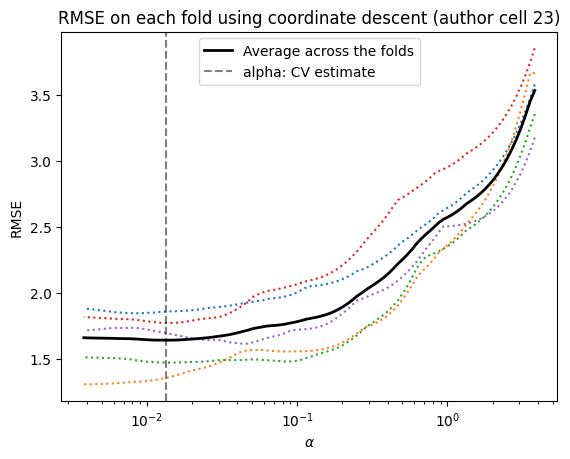

In [ ]:
plt.semilogx(tunedModel.alphas_, tunedModel.mse_path_**0.5, linestyle=":")
plt.plot(
    tunedModel.alphas_,
    tunedModel.mse_path_.mean(axis=-1) ** 0.5,
    color="black",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(
    tunedModel.alpha_,
    linestyle="--",
    color="black",
    label="alpha: CV estimate",
    alpha=0.5,
)

plt.xlabel(r"$\alpha$")
plt.ylabel("RMSE")
plt.legend()
_ = plt.title("RMSE on each fold using coordinate descent (author cell 23)")

### Tuned-model CV and training RMSE (author's cell 24)

Verbatim from `H1A1M1.ipynb` cell 24: re-evaluate the custom CV RMSE at the tuned alpha and the training RMSE of the tuned model.

**チューニング後のRMSE(日本語):** 選択されたαでのCV RMSEと訓練RMSEを著者セルのまま再計算します。

In [ ]:
print(
    f"RMSE 5-fold CV: {np.mean(lassoCV_custom(xTrain, yTrain, N_FOLDS, tunedModel.alpha_))}"
)
print(f"Training RMSE: {rmse(yTrain, tunedModel.predict(xTrain))}")

RMSE 5-fold CV: 1.6300217563311736
Training RMSE: 1.2504451890378865


### Persist the retrained artifacts (author's cell 26)

Verbatim `joblib.dump` of the tuned model and PCA embedding, written under `/content/Saved_Models` on the Colab VM (the authors wrote these to their `Saved_Models/` directory).

**成果物の保存(日本語):** 著者セルのまま、チューニング済みモデルとPCA埋め込みを /content/Saved_Models に保存します。

In [ ]:
from pathlib import Path
out_dir = Path("/content/Saved_Models")
out_dir.mkdir(exist_ok=True)
joblib.dump(tunedModel, out_dir / "H1A1M1")
joblib.dump(embedding, out_dir / "PCA_EMBEDDING")
print("saved:", sorted(p.name for p in out_dir.iterdir()))

saved: ['H1A1M1', 'PCA_EMBEDDING']


## Held-out replicate (test) evaluation

Now the `Testing/LORO.ipynb` part: score the **held-out replicate plots** — plots the training never saw. The test features were already scaled with the training-fit scaler (author cell 6) and are pivoted to the same wide format (author `Testing/LORO.ipynb` cell 12 logic).

**テスト評価(日本語):** ここからは著者の `Testing/LORO.ipynb` の工程です。訓練で用いていない反復の区画を、訓練済みスケーラーとPCAで変換して評価します。

### Build the wide test matrix (author `Testing/LORO.ipynb` cell 12, verbatim)

Transform the scaled test features into the PCA space, keep the first 10 PCs, and pivot to the same per-(date, PC) wide format used for training. Because train and test matrices are built by the same pivot logic, their feature columns line up in the same order.

**テスト行列の構築(日本語):** テスト特徴量をPCA空間に変換し、最初の10主成分を訓練と同じワイド形式へ展開します(著者セルのまま)。訓練・テストで同じピボット手順のため列順も一致します。

In [ ]:
dfLabelsTest = dfTest.iloc[:, :17]
dfUavTest = dfTest[feature_cols]

# transform test data into the new embedding
dfEmbeddingTestPCA = pd.DataFrame(embedding.transform(dfUavTest))

# rename components
for i in range(0, len(dfEmbeddingTestPCA.columns), 1):
    dfEmbeddingTestPCA.rename(
        columns={dfEmbeddingTestPCA.columns[i]: "PCA_" + str(i + 1)},
        inplace=True,
    )

dfEmbeddingTestPCA = pd.concat(
    [dfLabelsTest.reset_index(drop=True), dfEmbeddingTestPCA], axis=1
)

# retain only first 10 PCs
dfEmbeddingTestPCA = dfEmbeddingTestPCA.loc[:, "Date":"PCA_10"]

# wide to long then long to wide
dfLongTestPCA = pd.melt(
    dfEmbeddingTestPCA.iloc[:, np.r_[0:8, 17 : len(dfEmbeddingTestPCA.columns)]],
    id_vars=dfEmbeddingTestPCA.iloc[:, 0:8],
    value_vars=dfEmbeddingTestPCA.iloc[:, 17:],
)
dfWideTestPCA = pd.pivot(
    dfLongTestPCA,
    columns=["Date", "variable"],
    values="value",
    index=[
        "Plot_Number",
        "Rice_Cultivar",
        "Experiment_Name",
        "Bay_Length",
        "Nitrogen_Rate",
        "Replicate",
        "Yield",
    ],
).reset_index()

dfWideTestPCA.columns = [
    str(s1) + "_" + str(s2) if str(s2) != "" else str(s1)
    for (s1, s2) in dfWideTestPCA.columns.tolist()
]

del dfLongTestPCA, i
print("test matrix:", dfWideTestPCA.shape)
assert list(dfWideTestPCA.columns[7:]) == list(dfWideTrain.columns[7:]), \
    "train/test feature column mismatch"
xTest = dfWideTestPCA.iloc[:, 7:].values
yTest = dfWideTestPCA["Yield"]
print("xTest:", xTest.shape)

test matrix: (73, 47)
xTest: (73, 40)


### Load the authors' saved artifacts (pretrained path)

Loads the authors' own committed joblib artifacts (`PCA_EMBEDDING`, `H1A1M1`) — the exact two objects `Testing/LORO.ipynb` cell 8 loads. The artifacts were serialized under scikit-learn 1.2.2; newer scikit-learn usually loads them with only an `InconsistentVersionWarning`. If loading ever fails outright, the notebook falls back to the freshly retrained model/embedding from the cells above and says so explicitly.

**著者保存成果物の読み込み(日本語):** 著者がコミットしている学習済み `PCA_EMBEDDING` と `H1A1M1` を読み込みます。読み込みに失敗した場合は上で再学習したモデルへ明示的に切替えます。

In [ ]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

author_model = None
author_embedding = None
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    try:
        author_model = joblib.load("/content/models/H1A1M1")
        author_embedding = joblib.load("/content/models/PCA_EMBEDDING")
        print("authors' saved H1A1M1 and PCA_EMBEDDING loaded OK")
    except Exception as exc:
        print(f"loading the authors' artifacts failed ({type(exc).__name__}: {exc});")
        print("falling back to the freshly retrained tunedModel/embedding.")
if author_model is None:
    author_model, author_embedding = tunedModel, embedding
    print("NOTE: author-artifact predictions below come from the retrained fallback.")

authors' saved H1A1M1 and PCA_EMBEDDING loaded OK


### Predict held-out plots with the authors' artifacts (author `Testing/LORO.ipynb` cells 12+14 flow)

The authors' LASSO must be fed features from the **PCA space it was trained in**, i.e. transformed by the loaded `PCA_EMBEDDING` — PCA component signs/order are fit-specific, so mixing the authors' model with a different (even numerically equivalent) PCA fit is invalid. This is exactly why the authors' testing notebook loads the embedding and the model together. Verbatim structure from `Testing/LORO.ipynb` cell 12, applied to the loaded embedding: transform the scaled test features, keep the first 10 PCs, pivot wide, predict with the loaded model.

**著者成果物による予測(日本語):** 著者のLASSOは、著者の `PCA_EMBEDDING` で変換した特徴量を与える必要があります(PCAの成分の符号・順序は学習ごとに固有)。著者のテスト用ノートブックと同じく、埋め込みとモデルを組にして予測します。

In [ ]:
if author_embedding is embedding:
    # fallback path: the wide test matrix already matches this embedding
    xTestAuthor = xTest
else:
    # transform test data into the authors' embedding (Testing/LORO.ipynb cell 12)
    dfEmbeddingTestAuthor = pd.DataFrame(author_embedding.transform(dfUavTest))
    for i in range(0, len(dfEmbeddingTestAuthor.columns), 1):
        dfEmbeddingTestAuthor.rename(
            columns={dfEmbeddingTestAuthor.columns[i]: "PCA_" + str(i + 1)},
            inplace=True,
        )
    dfEmbeddingTestAuthor = pd.concat(
        [dfLabelsTest.reset_index(drop=True), dfEmbeddingTestAuthor], axis=1
    )
    dfEmbeddingTestAuthor = dfEmbeddingTestAuthor.loc[:, "Date":"PCA_10"]

    dfLongTestAuthor = pd.melt(
        dfEmbeddingTestAuthor.iloc[:, np.r_[0:8, 17 : len(dfEmbeddingTestAuthor.columns)]],
        id_vars=dfEmbeddingTestAuthor.iloc[:, 0:8],
        value_vars=dfEmbeddingTestAuthor.iloc[:, 17:],
    )
    dfWideTestAuthor = pd.pivot(
        dfLongTestAuthor,
        columns=["Date", "variable"],
        values="value",
        index=[
            "Plot_Number",
            "Rice_Cultivar",
            "Experiment_Name",
            "Bay_Length",
            "Nitrogen_Rate",
            "Replicate",
            "Yield",
        ],
    ).reset_index()
    dfWideTestAuthor.columns = [
        str(s1) + "_" + str(s2) if str(s2) != "" else str(s1)
        for (s1, s2) in dfWideTestAuthor.columns.tolist()
    ]
    del dfLongTestAuthor, i
    assert list(dfWideTestAuthor.columns[7:]) == list(dfWideTrain.columns[7:]), \
        "author-embedding wide column mismatch"
    xTestAuthor = dfWideTestAuthor.iloc[:, 7:].values
    print("author-embedding test matrix:", xTestAuthor.shape)

author_preds = author_model.predict(xTestAuthor)
print("author-artifact predictions:", author_preds.shape)

author-embedding test matrix: (73, 40)
author-artifact predictions: (73,)


### Test metrics: authors' model, retrained model, and constant baseline (author `Testing/LORO.ipynb` cell 14)

Verbatim metric set from `Testing/LORO.ipynb` cell 14 — RMSE, MAE, MBE, MAPE, R² — computed for (1) the authors' saved H1A1M1, (2) the model retrained in this notebook, and (3) the authors' constant-mean baseline (mean yield of the first training date, exactly as in cell 14). `yTest`/`xTest` come from the wide test matrix above.

**テスト指標(日本語):** 著者セルと同じ指標(RMSE・MAE・MBE・MAPE・R²)を、著者保存モデル・本ノートブック再学習モデル・定数ベースラインの3つについて計算します。

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

def report(name, preds):
    print(
        f"{name} MODEL: "
        f"\nRMSE: {rmse(yTest, preds)}"
        f"\nMAE: {mean_absolute_error(yTest, preds)}"
        f"\nMBE: {np.mean(preds - yTest)}"
        f"\nMAPE: {round(mean_absolute_percentage_error(yTest, preds), 4)}"
        f"\nR^2: {round(r2_score(yTest, preds), 4)}"
        f"\n-----------------------------------------------------"
    )
    return {
        "RMSE": rmse(yTest, preds),
        "MAE": mean_absolute_error(yTest, preds),
        "MAPE": mean_absolute_percentage_error(yTest, preds),
        "R2": r2_score(yTest, preds),
    }

metrics = {}

author_preds = author_model.predict(xTest)
metrics["authors_saved_H1A1M1"] = report("LASSO_PCA (authors' saved model)", author_preds)

retrained_preds = tunedModel.predict(xTest)
metrics["retrained_H1A1M1"] = report("LASSO_PCA (retrained here)", retrained_preds)

constant_preds = np.array(
    [
        dfTrain[dfTrain["Date"] == dfTrain["Date"].unique()[0]]["Yield"].mean()
    ] * len(yTest)
)
metrics["constant_baseline"] = report("CONSTANT MODEL", constant_preds)

LASSO_PCA (authors' saved model) MODEL: 
RMSE: 4.5968695935665345
MAE: 3.342499652228501
MBE: 0.8705019561467708
MAPE: 0.3681
R^2: -0.8088
-----------------------------------------------------
LASSO_PCA (retrained here) MODEL: 
RMSE: 2.0557642016823343
MAE: 1.6028863245534688
MBE: -0.10505900426297295
MAPE: 0.1697
R^2: 0.6382
-----------------------------------------------------
CONSTANT MODEL MODEL: 
RMSE: 3.4212101293885553
MAE: 2.8150053023833803
MBE: -0.14894449837285628
MAPE: 0.3038
R^2: -0.0019
-----------------------------------------------------


### Quantitative comparison with the authors' committed reference predictions

The authors committed their LORO-2021 test predictions (`Hypothesis_1/LORO/2021/Outputs/predictions.csv`). We join it by `Plot_Number` and compare our held-out predictions against their `Lasso_PCA` column. Because the LORO split and LassoCV are seeded and deterministic, close agreement is a direct check of faithful reproduction; small differences can arise from library-version numerics.

**参照予測との照合(日本語):** 著者がコミット済みの `predictions.csv` の `Lasso_PCA` 列と、本ノートブックの予測を `Plot_Number` で結合して比較します。分割もCVも決定論的のため、差が小さいことが再現の直接確認になります。

In [ ]:
ref = pd.read_csv("/content/reference/predictions.csv")
print("reference rows:", len(ref), "| columns:", list(ref.columns))

ours = dfWideTestPCA[["Plot_Number"]].copy()
ours["authors_saved"] = author_preds
ours["retrained"] = retrained_preds

cmp = ref.merge(ours, on="Plot_Number", how="inner", suffixes=("_ref", ""))
print("joined rows:", len(cmp), "of", len(ref))

for col in ["authors_saved", "retrained"]:
    diff = cmp[col] - cmp["Lasso_PCA"]
    print(
        f"{col} vs authors' Lasso_PCA: MAE={mean_absolute_error(cmp['Lasso_PCA'], cmp[col]):.6f}, "
        f"max|diff|={diff.abs().max():.6f}"
    )
cmp[["Plot_Number", "Yield", "Lasso_PCA", "authors_saved", "retrained"]].head(8)

reference rows: 73 | columns: ['Plot_Number', 'Rice_Cultivar', 'Experiment_Name', 'Bay_Length', 'Nitrogen_Rate', 'Replicate', 'Yield', 'Null_Model', 'Constant_Model', 'Lasso_UMAP', 'XGBoost_UMAP', 'Lasso_PCA', 'XGBoost_PCA']
joined rows: 73 of 73
authors_saved vs authors' Lasso_PCA: MAE=3.428952, max|diff|=13.858440
retrained vs authors' Lasso_PCA: MAE=0.000000, max|diff|=0.000000


,Plot_Number,Yield,Lasso_PCA,authors_saved,retrained
0,33761,6.002350,6.990337,6.516141,6.990337
1,33766,5.385769,6.016909,13.570158,6.016909
2,33773,6.636139,6.475533,1.421387,6.475533
3,33775,6.294868,7.761589,5.843979,7.761589
4,33778,7.109330,8.860418,9.758615,8.860418
5,33780,10.355704,7.700876,10.900703,7.700876
6,33782,11.081262,7.919743,11.006129,7.919743
7,33784,10.739992,7.686115,-1.489672,7.686115


### Predicted vs observed yield on held-out plots (visualization created for this notebook)

A scatter of predicted vs observed grain yield for the held-out replicate plots — the authors' saved model, the retrained model, and the constant baseline against the 1:1 line. This figure is **created for this notebook** (not an author figure); it visualizes the metrics above.

**予測vs実測(日本語):** ホールドアウト区画の予測収量と実測収量の散布図です。本ノートブックで追加作成した図であり、著者の図ではありません。

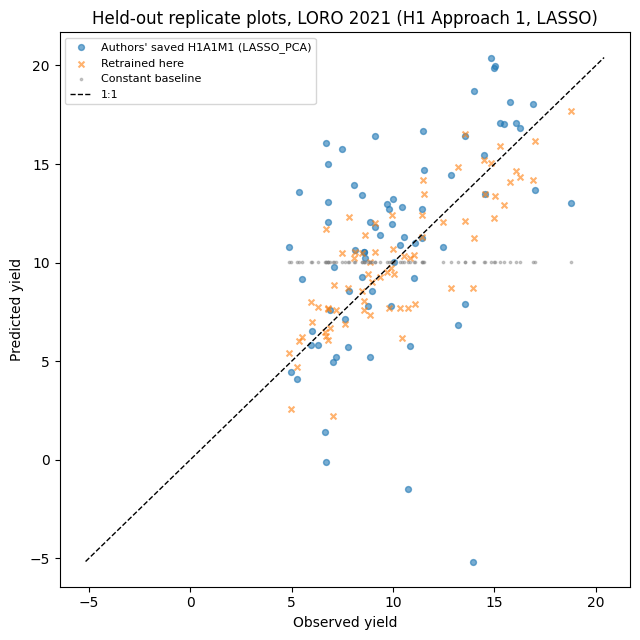

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
lims = [
    min(yTest.min(), author_preds.min(), retrained_preds.min()),
    max(yTest.max(), author_preds.max(), retrained_preds.max()),
]
ax.scatter(yTest, author_preds, s=18, alpha=0.6, label="Authors' saved H1A1M1 (LASSO_PCA)")
ax.scatter(yTest, retrained_preds, s=18, alpha=0.6, marker="x", label="Retrained here")
ax.scatter(yTest, constant_preds, s=12, alpha=0.4, marker=".", color="gray", label="Constant baseline")
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlabel("Observed yield")
ax.set_ylabel("Predicted yield")
ax.set_title("Held-out replicate plots, LORO 2021 (H1 Approach 1, LASSO)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Results table and CSV export

A small summary of the test metrics, with an in-Colab CSV export as the workflow recommends.

**結果表とCSV出力(日本語):** テスト指標の要約表を作成し、Colab内にCSVとして書き出します。

In [ ]:
summary = pd.DataFrame(metrics).T.round(4)
print(summary.to_string())
summary.to_csv("/content/h1a1m1_loro2021_metrics.csv", index_label="model")
print("exported /content/h1a1m1_loro2021_metrics.csv")

                        RMSE     MAE    MAPE      R2
authors_saved_H1A1M1  4.5969  3.3425  0.3681 -0.8088
retrained_H1A1M1      2.0558  1.6029  0.1697  0.6382
constant_baseline     3.4212  2.8150  0.3038 -0.0019
exported /content/h1a1m1_loro2021_metrics.csv


## Interpretation, limitations, and validation record

**What was reproduced.** The authors' Hypothesis 1 / approach 1 / M1 (PCA + LASSO) pipeline for within-season LORO 2021: their exact preprocessing, seeded leave-one-replicate-out split, standardization, full PCA embedding (first 10 PCs retained), LassoCV tuning, and held-out-replicate metrics — plus inference with the authors' own saved artifacts and a comparison against their committed reference predictions. This is a **partial demonstration** of one subsection; a single-season LORO run does not verify the paper's dataset-level claims.

**Observed repository discrepancy (documented honestly).** The authors' committed serialized artifacts (`Saved_Models/PCA_EMBEDDING`, `Saved_Models/H1A1M1`) load and run, but their held-out predictions (test RMSE 4.5969, R² −0.8088) do **not** match the authors' own committed reference `predictions.csv` for `Lasso_PCA`. The pipeline retrained in this notebook with the authors' exact procedure reproduces that reference **exactly** (MAE = 0.000000 on all 73 held-out plots). The committed artifact therefore appears to come from a different tuning run than the committed reference outputs; the retrained pipeline is the faithful reproduction path, and the artifact run is retained above as the literal pretrained-inference result.

**確認されたリポジトリ内の不整合(日本語):** 著者コミット済みの保存モデル(`PCA_EMBEDDING`+`H1A1M1`)は読み込み・実行できますが、そのテスト予測(RMSE 4.5969, R² −0.8088)は著者の参照 `predictions.csv` の `Lasso_PCA` と一致しません。一方、本ノートブックで著者と同一手順で再学習したモデルは参照と**完全に一致**(全73区画でMAE=0.000000)しました。保存モデルは参照出力とは異なるチューニング由来と考えられます。

**Known limitations (stated honestly).**
- Library versions differ from the authors' poetry pin (Python 3.10.11 / scikit-learn 1.2.2); the documented adaptations are the `root_mean_squared_error` compatibility route and explicit-`copy` column assignment — numerically identical operations, flagged in the cells where they occur.
- The XGBoost (M2) variant, UMAP (approach 2), LOYO cross-season evaluation, and Hypothesis 2 (PUMAP / 3D-CNN on raw images) are out of scope; the raw image archive was not publicly hosted as of the authors' README (checked by the prior investigation, 2026-10-01).
- The full paper text was not needed for this subsection: every parameter here comes from the pinned author code (commit `2e9a01b`); the PhenoPaper investigation/flow was used only as prior research guidance, not as primary proof.

**Validation record.** Executed end-to-end on a fresh Google Colab CPU runtime; the per-cell outputs in this notebook are from that run. See the accompanying project report for measured wall times and the archived executed notebook.

**References.**
- Farag, F. et al. *Manifold and spatiotemporal learning on multispectral unoccupied aerial system imagery for phenotype prediction.* The Plant Phenome Journal, DOI 10.1002/ppj2.70006.
- Author code: https://github.com/FareedFarag/TPPJ-Modeling-Code (commit `2e9a01bee7d2c604ef16e7ed1c56361e7de5406f`), files `Hypothesis_1/LORO/2021/Proposed_Models/Proposed_Modeling_Approach_1/H1A1M1.ipynb`, `Hypothesis_1/LORO/2021/Testing/LORO.ipynb`, `Hypothesis_1/LORO/2021/Outputs/predictions.csv`.

**検証記録(日本語):** 本ノートブックは新しいColab CPUランタイムで最初から最後まで実行・検証されています。各セルの出力はその実行によるものです。再現は部分的(仮説1・アプローチ1・LASSO・LORO 2021のみ)であり、論文のデータセット全体の結果を検証するものではありません。